# K-Nearest Neighbors (KNN)

<center>
  <img src="https://miro.medium.com/max/1151/0*ItVKiyx2F3ZU8zV5"><br>
  image from: <a href="https://ai.plainenglish.io/introduction-to-k-nearest-neighbors-knn-algorithm-e8617a448fa8">Introduction to k-Nearest Neighbors (kNN) Algorithm | by Rajvi Shah |  Artificial Intelligence in Plain English</a>
</center>

# Lab-1 Wine quality classification (Binary classification)
- ใช้ dataset จากไฟล์ `winequality.csv`
  1. **Fixed Acidity (ความเป็นกรดคงที่):** ปริมาณกรดในไวน์ที่ไม่ระเหยได้ง่าย มีความสำคัญในการให้รสชาติเปรี้ยว
  2. **Volatile Acidity (ความเป็นกรดระเหย):** ปริมาณกรดที่ระเหยได้ง่ายเช่น กรดแอซิติก ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีกลิ่นเหมือนน้ำส้มสายชู
  3. **Citric Acid (กรดซิตริก):** กรดที่พบในผลไม้ ให้รสชาติเปรี้ยวสดชื่นและช่วยเพิ่มความสดของไวน์
  4. **Residual Sugar (น้ำตาลที่เหลืออยู่):** ปริมาณน้ำตาลที่ยังเหลืออยู่หลังจากการหมัก ไวน์ที่มีน้ำตาลเหลือมากจะมีรสหวาน
  5. **Chlorides (คลอไรด์):** ปริมาณเกลือในไวน์ ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีรสเค็ม
  6. **Free Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์อิสระ):** ปริมาณซัลเฟอร์ไดออกไซด์ในไวน์ที่ไม่ได้ทำปฏิกิริยากับสารอื่นๆ ช่วยป้องกันไวน์จากการออกซิเดชันและการเสียหายจากเชื้อรา
  7. **Total Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์ทั้งหมด):** ปริมาณรวมของซัลเฟอร์ไดออกไซด์ทั้งที่อิสระและที่ทำปฏิกิริยากับสารอื่นๆในไวน์
  8. **Density (ความหนาแน่น):** ความหนาแน่นของไวน์ ซึ่งมีความสัมพันธ์กับปริมาณน้ำตาลและแอลกอฮอล์ในไวน์
  9. **pH (ค่าความเป็นกรด-ด่าง):** ค่าที่แสดงความเป็นกรดหรือเบสของไวน์ ไวน์ทั่วไปจะมีค่า pH อยู่ระหว่าง 3 ถึง 4
  10. **Sulphates (ซัลเฟต):** สารประกอบที่ช่วยเพิ่มกลิ่นหอมของไวน์และป้องกันการเกิดออกซิเดชัน
  11. **Alcohol (แอลกอฮอล์):** ปริมาณแอลกอฮอล์ในไวน์ มีผลต่อรสชาติและความรู้สึกเมา
  12. **Quality (คุณภาพ):** คุณภาพของไวน์ 0 - Bad Wine, 1 - Good Wine

## Preparation

* เชื่อมต่อ google drive
* upload ไฟล์ winequality-red (binary).csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* สร้าง DataFrame จากไฟล์ winequality-red (binary).csv

In [ ]:
import pandas as pd
wine_df = pd.read_csv('/content/drive/MyDrive/ML dataset/winequality-red (binary).csv')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
wine_df.shape

(1599, 12)

In [ ]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## แบ่ง Train / Test Dataset

* ใช้ train_test_split จาก library sklearn.model_selection
```
from sklearn.model_selection import train_test_split
```

In [ ]:
from sklearn.model_selection import train_test_split

* เรียกใช้ train_test_split
```
train_test_split(X, y, test_size=?)
```

In [ ]:
y = wine_df.iloc[:,-1]
y

,quality
0,0
1,0
2,0
3,1
4,0
...,...
1594,0
1595,1
1596,1
1597,0


In [ ]:
X = wine_df.iloc[:,:-1]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=888)

In [ ]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1173,7.6,0.360,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5
1559,7.8,0.600,0.26,2.0,0.080,31.0,131.0,0.99622,3.21,0.52,9.9
870,7.7,0.715,0.01,2.1,0.064,31.0,43.0,0.99371,3.41,0.57,11.8
935,8.8,0.300,0.38,2.3,0.060,19.0,72.0,0.99543,3.39,0.72,11.8
27,7.9,0.430,0.21,1.6,0.106,10.0,37.0,0.99660,3.17,0.91,9.5
...,...,...,...,...,...,...,...,...,...,...,...
1139,8.2,0.510,0.24,2.0,0.079,16.0,86.0,0.99764,3.34,0.64,9.5
1174,7.6,0.360,0.31,1.7,0.079,26.0,65.0,0.99716,3.46,0.62,9.5
1263,8.2,0.780,0.00,2.2,0.089,13.0,26.0,0.99780,3.37,0.46,9.6
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6


In [ ]:
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
556,10.9,0.53,0.49,4.6,0.118,10.0,17.0,1.00020,3.07,0.56,11.7
1382,8.0,0.60,0.22,2.1,0.080,25.0,105.0,0.99613,3.30,0.49,9.9
15,8.9,0.62,0.19,3.9,0.170,51.0,148.0,0.99860,3.17,0.93,9.2
1067,11.1,0.31,0.53,2.2,0.060,3.0,10.0,0.99572,3.02,0.83,10.9
1056,8.9,0.48,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1
...,...,...,...,...,...,...,...,...,...,...,...
1112,7.9,0.33,0.41,1.5,0.056,6.0,35.0,0.99396,3.29,0.71,11.0
449,11.9,0.39,0.69,2.8,0.095,17.0,35.0,0.99940,3.10,0.61,10.8
888,6.8,0.57,0.00,2.5,0.072,32.0,64.0,0.99491,3.43,0.56,11.2
1035,10.1,0.37,0.34,2.4,0.085,5.0,17.0,0.99683,3.17,0.65,10.6


In [ ]:
y_test

,quality
556,1
1382,0
15,0
1067,1
1056,1
...,...
1112,1
449,1
888,1
1035,1


## สร้างโมเดล KNN

* ใช้ KNeighborsClassifier จาก library sklearn.neighbors
```
from sklearn.neighbors import KNeighborsClassifier
```

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

* สร้างโมเดลเปล่า
```
KNeighborsClassifier(n_neighbors=?)
```

In [ ]:
wine_cf = KNeighborsClassifier(n_neighbors=3)

* ให้โมเดลเรียนรู้ข้อมูลจาก training data
```
fit()
```

In [ ]:
wine_cf.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

* ทดสอบการ predict (classify) ด้วย testing data

In [ ]:
y_predict = wine_cf.predict(X_test)
y_predict

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,

In [ ]:
y_test

,quality
556,1
1382,0
15,0
1067,1
1056,1
...,...
1112,1
449,1
888,1
1035,1


## วัดประสิทธิภาพของโมเดลที่ได้

### Accuracy
ความแม่นยำในการทำนาย หรือสัดส่วนของการทำนายที่ถูกต้อง
```python
from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.69375

### Confusion Matrix and Classification Report

ตารางที่ใช้ในการแสดงผลการทำงานของโมเดลในการจำแนกประเภท (classification) โดยแสดงค่าทั้งหมดของ True Positives (TP), True Negatives (TN), False Positives (FP) และ False Negatives (FN)
```
                Predicted Negative   Predicted Positive
Actual Negative         TN                   FP
Actual Positive         FN                   TP
```
  * row - true label
  * column - predict label

```
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(true, predict)
print(classification_report(<true label>, <predicted label>))
```

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = (confusion_matrix(y_test, y_predict))
cm

array([[117,  53],
       [ 45, 105]])

In [ ]:
pd.DataFrame(cm, columns=wine_cf.classes_,index=wine_cf.classes_)
#row-คือค่าจริง col-คือค่าที่ทำนาย

,0,1
0,117,53
1,45,105


In [ ]:
# pd.DataFrame(confusion_matrix(y_test, y_predict), columns=['Bad','Good'])
pd.DataFrame(confusion_matrix(y_test, y_predict), columns=['Bad','Good'],index=['Bad','Good'])

,Bad,Good
Bad,117,53
Good,45,105


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.72      0.69      0.70       170
           1       0.66      0.70      0.68       150

    accuracy                           0.69       320
   macro avg       0.69      0.69      0.69       320
weighted avg       0.70      0.69      0.69       320



### AUC (Area Under the ROC Curve)

<center>
  <img src="https://i2.wp.com/sefiks.com/wp-content/uploads/2020/12/roc-curve-original.png"><br>
  imgae from: <a href="https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg">https://commons.wikimedia.org/wiki/File:Roc-draft-xkcd-style.svg</a>
</center>

- **ROC** - **R**eceiver **O**perating **C**haracteristic
  - กราฟที่ใช้ในการประเมินประสิทธิภาพของโมเดลการจำแนกประเภท (Classification Model) โดยแสดงความสัมพันธ์ระหว่าง True Positive Rate (TPR) กับ False Positive Rate (FPR) ในทุกๆ ค่าของ Threshold ที่ใช้ในการทำนายผล โมเดลที่ดีจะมีกราฟ ROC ที่อยู่ใกล้กับมุมบนซ้ายมากที่สุด
    - **True Positive Rate (TPR):** หรือ Sensitivity/Recall หมายถึงอัตราส่วนของค่าจริงที่เป็นบวกที่ถูกทำนายถูกต้อง โดยคำนวณจากสูตร TPR = TP / (TP + FN)
    - **False Positive Rate (FPR):** หมายถึงอัตราส่วนของค่าจริงที่เป็นลบที่ถูกทำนายผิดพลาด โดยคำนวณจากสูตร FPR = FP / (FP + TN)
- **AUC** - **A**rea **U**nder the **C**urve
  - ค่าพื้นที่ใต้กราฟ ROC ซึ่งใช้เป็นตัวชี้วัดประสิทธิภาพโดยรวมของโมเดลการจำแนกประเภท ค่า AUC จะอยู่ระหว่าง 0 ถึง 1 โดย:
    - ค่า AUC ใกล้เคียง 1 หมายความว่าโมเดลมีประสิทธิภาพสูง
    - ค่า AUC ใกล้เคียง 0.5 หมายความว่าโมเดลทำงานได้ไม่ดีกว่าเดาสุ่ม
    - ค่า AUC น้อยกว่า 0.5 หมายความว่าโมเดลมีประสิทธิภาพแย่กว่าการเดาสุ่ม (อาจเกิดจากการที่โมเดลกลับค่าทำนาย)

```python
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_true, y_pred, plot_chance_level=True)
```

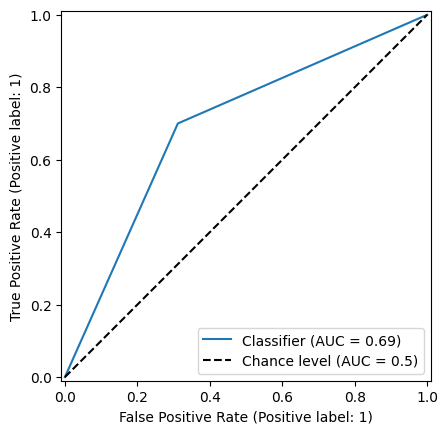

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_predict, plot_chance_level=True)

### Kappa (Cohen's Kappa)

การวัดความเห็นพ้องระหว่างผลการทำนายของโมเดลและค่าจริง

**สูตรการคำนวณ**:

$Kappa = \frac{P_o - P_e}{1 - P_e}$

- $P_o$: สัดส่วนความแม่นยำที่เกิดขึ้นจริง (observed accuracy)
- $P_e$: สัดส่วนความแม่นยำที่เกิดขึ้นแบบสุ่ม (expected accuracy)

```python
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test, y_predict)

np.float64(0.38702111024237684)

### MCC (Matthews Correlation Coefficient)

การวัดประสิทธิภาพของโมเดลโดยพิจารณาความสัมพันธ์ระหว่างค่าทำนายและค่าจริง

**สูตรการคำนวณ**:

$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$

```python
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_true, y_pred)
```

In [ ]:
from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, y_predict)

np.float64(0.38750655524123306)

## Prediction

* สร้าง DataFrame

  ```
  [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2]
  ```

In [ ]:
wine_new = pd.DataFrame([
    [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2],
    [2.9, 1.5, 1.12, 3.0, 1.075, 32.0, 30.0, 1, 3.57, 2.71, 9.2]], columns=X_test.columns)
wine_new

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,5.9,0.645,0.12,2.0,0.075,32.0,35.0,1,3.57,0.71,11.2
1,2.9,1.500,1.12,3.0,1.075,32.0,30.0,1,3.57,2.71,9.2


* Predict โดยใช้โมเดลเดิม

In [ ]:
wine_cf.predict(wine_new)

array([1, 1])